# Network Traffic Application Classification

**Overview:** This tutorial provides a comprehensive, systematic approach to building and evaluating machine learning models for network traffic application classification. We present a methodical framework that addresses the complete pipeline from systematic feature analysis and selection to comparative model evaluation. The tutorial emphasizes rigorous data preparation methodologies that ensure model generalizability and avoid common pitfalls such as data leakage and overfitting. By following this systematic approach, practitioners will develop robust traffic classification systems suitable for real-world deployment.

**Dataset:** The data used in this tutorial was generated using NFStream. The dataset contains 1,142,230 network flows with 89 features, representing diverse traffic patterns across various applications. Each flow is characterized by statistical, temporal, and protocol-specific features that capture the behavioral patterns of network communications.

---

## Project Repository Setup

Before we can start data preprocessing, we need to ensure that all the required files are downloaded. We begin with cloning only the required parts of the `ml-flow-class-tutorial` repository using a sparse checkout. We intentionally avoid downloading the full repo to keep the directory clean.

In [1]:
# Clone the repo but leave the directory empty
!git clone --filter=blob:none --sparse -n https://github.com/FlowFrontiers/ml-flow-class-tutorial.git 2> >(grep -v '^remote:')

# Navigate into the repo and select only the data files we need
!cd ml-flow-class-tutorial && git sparse-checkout set 02-app-classification/requirements-dataprep.txt 02-app-classification/data/data.parquet
!cd ml-flow-class-tutorial && git checkout 2> >(grep -v '^remote:')

# Navigate to the working directory
import os
os.chdir('ml-flow-class-tutorial/02-app-classification')

Cloning into 'ml-flow-class-tutorial'...
Your branch is up to date with 'origin/main'.


After this step, we have:
- the `data/` directory with a Parquet file containing flow records
- the `requirements-dataprep.txt` script

Next, we install the required Python packages.

In [2]:
# Install the required packages
!pip install -r requirements-dataprep.txt 2>&1 | grep -E "(Instal|Update|Setup|ERROR|FAILED)"

---

## 1. Dataset Provenance

### 1.2. Data Collection Context

Raw packet data were organized into structured flow records via NFStream. The framework was configured with accounting mode set to 2 (transport layer), which reports byte-related features at the transport layer level including protocol headers. This configuration provides consistent byte accounting across mixed IPv4 and IPv6 traffic without requiring compensation for variable network layer header sizes. Additionally, Berkeley Packet Filter (BPF) rules were applied to restrict capture to TCP and UDP packets exclusively.

The NFStream configuration used for this measurement:

```python
streamer = NFStreamer(
    source='enp14s0f0',
    accounting_mode=2,
    n_dissections=20,
    statistical_analysis=True,
    splt_analysis=25,
    bpf_filter="\\tcp or \\udp",
)
```

The packet capture system was deployed on a university network infrastructure spanning multiple geographical locations across two cities. The capture was performed using a Switched Port Analyzer (SPAN) port that mirrors traffic from the university's network uplink, aggregating communications from both university facilities and dormitory buildings interconnected via fiber optic infrastructure. To ensure accurate packet capture at the configured 1500 byte MTU,
 * TCP Segmentation Offload (TSO),
 * Generic Segmentation Offload (GSO),
 * Generic Receive Offload (GRO), and
 * Large Receive Offload (LRO)
features were disabled on the capture interface.

Data collection was conducted on Friday, 2025-07-11 for approximately 75 minutes. During this measurement period, the system maintained an average capture throughput of 1.67 Gbit/s at 0.20 Mpps, successfully processing a total of 8,911,135,555 packets. The relatively low throughput reflects the summer holiday period when most students were not occupying the dormitories, combined with Friday evening hours when university staff were not present, resulting in lower network activity from both user populations.

---

### 1.3. Data Anonymization Method

To protect the privacy of network users and comply with ethical research standards, the dataset was subjected to a rigorous anonymization process before analysis. All IP addresses, both source and destination, were anonymized in a way that preserves the analytical integrity of the data while making it computationally infeasible to identify the original network participants.

While NFStream provides a robust built-in anonymization feature using the Blake2 hashing algorithm, for this tutorial, we have implemented a custom **SHA-256 based approach**. This allows us to provide a transparent, step-by-step explanation of the principles behind sound data anonymization.

The core of our method is a **deterministic, cryptographically-secure hashing** technique. Each source and destination IP address (both IPv4 and IPv6) is hashed using the **SHA-256 algorithm** with a secret, private salt. The resulting hash is then truncated and mapped to a valid, format-preserving IP address.

A few examples of the anonymization process are shown below:

| Original IP         | Anonymized IP       |
| :------------------ | :------------------ |
| `117.131.191.2`     | `155.202.56.96`     |
| `185.25.182.51`     | `71.209.188.228`    |
| `2a00:1450:4001::1` | `d3e4:f5a6:b7c8::1` |

This approach provides several critical guarantees essential for academic research:

*   **Deterministic Mapping:** Each original IP address maps consistently to the exact same anonymized address throughout the entire dataset. This is crucial for preserving the integrity of network flows and user behavior patterns. In our dataset, this process successfully preserved the **13,609 unique source IPs** and **50,630 unique destination IPs** present in the original capture.
*   **Non-Reversibility:** The use of a cryptographic hash with a secret salt makes the process non-reversible. It is computationally infeasible to derive the original IP addresses from the anonymized ones.
*   **Structural Preservation:** This method ensures that while individual privacy is protected, the essential structural properties of the network traffic are perfectly preserved, maintaining the dataset's high value for our classification task.

---

---

## 2. A Systematic Data Preparation Workflow

The success of any machine learning model depends fundamentally on the quality and appropriateness of the features used for training. In network traffic classification, this principle is critical due to the complex nature of network data and the potential for subtle data leakage, which can lead to models that perform well in laboratory settings but fail in real-world deployment.

Our approach follows a rigorous five-step process:
1.  **Feature Exploration:** Understanding the structure and semantics of the raw data.
2.  **Data Quality Assessment:** Identifying missing values, inconsistencies, or unusable features.
3.  **Dependency Analysis:** Investigating how features interact with each other and the underlying network protocols.
4.  **Feature Selection:** Making principled decisions to retain only generalizable, high-quality features.
5.  **Target Analysis:** Understanding the distribution and challenges of what we aim to predict.

### 2.1. Foundational Data Exploration

We begin by loading our dataset and conducting a comprehensive initial survey. Unlike many tutorials that rush to modeling, we take a methodical approach to understanding our data's structure and semantics.

#### 2.1.1. Initial Data Loading and Structure

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset from the Parquet file
df = pd.read_parquet('data/data.parquet')

# Display the shape and basic information
print(f"Dataset shape: {df.shape}")
print(f"Total network flows: {df.shape[0]:,}")
print(f"Total features: {df.shape[1]:,}")

# Get a comprehensive view of all features and their data types
print("\nAll features in the dataset:")
print("=" * 50)
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col:<35} {str(df[col].dtype):<12}")

# Display the first few rows to understand the data structure
print("\nFirst 5 rows of the dataset:")
pd.set_option('display.max_columns', None)
print(df.head())

Dataset shape: (1142230, 89)
Total network flows: 1,142,230
Total features: 89

All features in the dataset:
 1. id                                  int32       
 2. expiration_id                       int8        
 3. src_ip                              object      
 4. src_mac                             object      
 5. src_oui                             object      
 6. src_port                            int32       
 7. dst_ip                              object      
 8. dst_mac                             object      
 9. dst_oui                             object      
10. dst_port                            int32       
11. protocol                            int8        
12. ip_version                          int8        
13. vlan_id                             int8        
14. tunnel_id                           int8        
15. bidirectional_first_seen_ms         int64       
16. bidirectional_last_seen_ms          int64       
17. bidirectional_duration_ms           int

**Initial Observations:** We have a substantial dataset containing **1,142,230 flows** and a rich set of **89 features**. The feature names suggest a mix of identifiers (`src_ip`), metadata (`expiration_id`), detailed statistical metrics (`bidirectional_mean_ps`), sequence data (`splt_ps`), and potential labels (`application_name`). The data types are mostly numerical, which is suitable for machine learning, but several important columns are `object` type (like IPs, labels, and the SPLT lists), which will require special handling.

#### 2.1.2. Understanding Feature Semantics Through Categorization

With 89 features, we must move beyond a simple list and understand their meaning in a networking context. By consulting the [NFStream documentation](https://www.nfstream.org/docs/api#nflow) and analyzing the feature names, we can organize them into distinct semantic categories. This categorization is crucial for understanding their potential utility and risks for machine learning.

In [4]:
# Systematic feature categorization based on networking semantics
# This categorization helps us understand the role and appropriateness of each feature
feature_categories = {
    'Identifiers_and_Metadata': [
        'id', 'expiration_id', 'src_ip', 'dst_ip', 'src_mac', 'dst_mac',
        'src_oui', 'dst_oui', 'src_port', 'dst_port', 'protocol', 'ip_version',
        'vlan_id', 'tunnel_id'
    ],
    'Temporal_Features': [
        'bidirectional_first_seen_ms', 'bidirectional_last_seen_ms', 'bidirectional_duration_ms',
        'src2dst_first_seen_ms', 'src2dst_last_seen_ms', 'src2dst_duration_ms',
        'dst2src_first_seen_ms', 'dst2src_last_seen_ms', 'dst2src_duration_ms'
    ],
    'Volume_Features': [
        'bidirectional_packets', 'src2dst_packets', 'dst2src_packets',
        'bidirectional_bytes', 'src2dst_bytes', 'dst2src_bytes'
    ],
    'Packet_Size_Statistics': [
        'bidirectional_min_ps', 'bidirectional_mean_ps', 'bidirectional_stddev_ps', 'bidirectional_max_ps',
        'src2dst_min_ps', 'src2dst_mean_ps', 'src2dst_stddev_ps', 'src2dst_max_ps',
        'dst2src_min_ps', 'dst2src_mean_ps', 'dst2src_stddev_ps', 'dst2src_max_ps'
    ],
    'Inter_Arrival_Time_Statistics': [
        'bidirectional_min_piat_ms', 'bidirectional_mean_piat_ms', 'bidirectional_stddev_piat_ms', 'bidirectional_max_piat_ms',
        'src2dst_min_piat_ms', 'src2dst_mean_piat_ms', 'src2dst_stddev_piat_ms', 'src2dst_max_piat_ms',
        'dst2src_min_piat_ms', 'dst2src_mean_piat_ms', 'dst2src_stddev_piat_ms', 'dst2src_max_piat_ms'
    ],
    'TCP_Protocol_Features': [
        'bidirectional_syn_packets', 'bidirectional_cwr_packets', 'bidirectional_ece_packets', 'bidirectional_urg_packets',
        'bidirectional_ack_packets', 'bidirectional_psh_packets', 'bidirectional_rst_packets', 'bidirectional_fin_packets',
        'src2dst_syn_packets', 'src2dst_cwr_packets', 'src2dst_ece_packets', 'src2dst_urg_packets',
        'src2dst_ack_packets', 'src2dst_psh_packets', 'src2dst_rst_packets', 'src2dst_fin_packets',
        'dst2src_syn_packets', 'dst2src_cwr_packets', 'dst2src_ece_packets', 'dst2src_urg_packets',
        'dst2src_ack_packets', 'dst2src_psh_packets', 'dst2src_rst_packets', 'dst2src_fin_packets'
    ],
    'Sequence_Features': [
        'splt_direction', 'splt_ps', 'splt_piat_ms'
    ],
    'Application_Layer_Features': [
        'application_is_guessed', 'application_confidence', 'requested_server_name',
        'client_fingerprint', 'server_fingerprint', 'user_agent', 'content_type'
    ],
    'Target_Variables': [
        'application_name', 'application_category_name'
    ]
}

# Display categorization summary
print("Feature Categorization Summary:")
print("=" * 50)
total_features_categorized = 0
for category, features in feature_categories.items():
    print(f"{category.replace('_', ' ')}: {len(features)} features")
    total_features_categorized += len(features)
print("-" * 50)
print(f"Total features categorized: {total_features_categorized}")

Feature Categorization Summary:
Identifiers and Metadata: 14 features
Temporal Features: 9 features
Volume Features: 6 features
Packet Size Statistics: 12 features
Inter Arrival Time Statistics: 12 features
TCP Protocol Features: 24 features
Sequence Features: 3 features
Application Layer Features: 7 features
Target Variables: 2 features
--------------------------------------------------
Total features categorized: 89


**Analysis of Feature Categories:**

This categorization reveals the diversity of information captured.
- **Identifiers and Metadata:** This group contains basic network addressing (IPs, ports), hardware identifiers (MACs), and metadata added by NFStream (`id`, `expiration_id`). Most of these are not generalizable and will be excluded from the model.
- **Temporal and Volume Features:** These capture the "what" and "how much" of a flow: its duration and the volume of packets/bytes transferred.
- **Packet Size and Inter-arrival Time Statistics:** These provide detailed behavioral patterns that are highly discriminative.
- **TCP Protocol Features:** These indicate the state and control flow of TCP connections.
- **Sequence Features:** The `splt_*` columns contain the raw sequence of directions, sizes, and timings for the first few packets. These offer a granular, alternative view to the statistical summaries and will be the focus of a separate experiment.
- **Application Layer Features:** This diverse group contains metadata extracted by the DPI engine, such as TLS fingerprints, server names, and confidence scores. These are powerful but carry a high risk of data leakage if not handled with care.
- **Target Variables:** The `application_name` and `application_category_name` are what we aim to predict.
  
This structured view allows us to anticipate which features might be generalizable (e.g., statistics) and which might cause overfitting (e.g., IP addresses).

----

### 2.2. Data Quality Assessment

Before proceeding to deeper analysis, we must assess the quality and completeness of the data. In machine learning, "garbage in, garbage out" holds true. In network traffic analysis, data quality issues often manifest as missing values or constant features, which can significantly impact model performance.

#### 2.2.1. Missing Value Analysis

Let's systematically check for missing (null) values across all 89 features.

In [5]:
# Examine missing values across all features
missing_analysis = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})

# Display only columns with missing values
missing_features = missing_analysis[missing_analysis['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)

print("Missing Value Analysis:")
print("=" * 40)
print(missing_features)

Missing Value Analysis:
                       Missing_Count  Missing_Percentage
content_type                 1123978           98.402073
user_agent                   1113933           97.522653
server_fingerprint            903244           79.077244
client_fingerprint            787454           68.940056
requested_server_name         375341           32.860370


**Observation:**
The analysis reveals that five features related to the application layer have a significant number of missing (`NaN`) values. The `content_type` and `user_agent` are almost always missing, as they are specific to unencrypted HTTP traffic. More importantly, the `server_fingerprint`, `client_fingerprint`, and `requested_server_name` also have high percentages of missing data (79%, 69%, and 33% respectively).

This pattern strongly suggests **structural missingness** rather than random data corruption. The values are missing by design because these features are protocol-specific. For example, fingerprints are only generated for TLS/SSH/QUIC traffic, and the server name is only available if a protocol like TLS (via SNI) or HTTP (via Host header) exposes it. All core statistical, temporal, and volume features are complete.

#### 2.2.2. Special Value Analysis: "Unknown" and "Unspecified" Labels

In addition to standard `NaN` (Not a Number) missing values, network datasets often contain specific string placeholders that also represent missing or invalid data. For our potential target variables, `application_name` and `application_category_name`, we must check for the presence of `"Unknown"` or `"Unspecified"` labels, as these flows cannot be used for supervised training.

In [6]:
# Examine "Unknown" and "Unspecified" values
unknown_analysis = pd.DataFrame({
    'Unknown_Count': [
        (df['application_name'] == 'Unknown').sum(),
        (df['application_category_name'] == 'Unspecified').sum()
    ],
    'Unknown_Percentage': [
        (df['application_name'] == 'Unknown').sum() / len(df) * 100,
        (df['application_category_name'] == 'Unspecified').sum() / len(df) * 100
    ]
}, index=['application_name', 'application_category_name'])

# Display only columns with unknown/unspecified values
unknown_features = unknown_analysis[unknown_analysis['Unknown_Count'] > 0].sort_values('Unknown_Percentage', ascending=False)

print("Unknown/Unspecified Value Analysis:")
print("=" * 40)
print(unknown_features)

Unknown/Unspecified Value Analysis:
                           Unknown_Count  Unknown_Percentage
application_name                   38417            3.363333
application_category_name          38417            3.363333


**Observation:**
Our analysis shows that **3.4% of our flows** could not be identified by the nDPI engine, resulting in an `application_name` of `"Unknown"` and a corresponding `application_category_name` of `"Unspecified"`. This is a critical data quality finding for several reasons:

1.  **It's a "Catch-All" Bin:** The `"Unknown"` label does not represent a single type of traffic. Instead, it is a **heterogeneous mixture** of many different flows that nDPI could not classify. This could include traffic from novel applications, proprietary or obfuscated protocols, or sessions where the identifying handshake was not captured.

2.  **It's Unsuitable for Training:** Because this class is a mix of diverse and unrelated traffic patterns, treating it as a single target class would be problematic. A model would struggle to find a consistent pattern, and it would be impossible to meaningfully evaluate its performance on this class since we have **no reliable ground truth**.

While one could attempt to build a model that includes an "Unknown" class, for the purposes of this tutorial, our goal is to accurately classify *known* applications. Including this ambiguous category would compromise the integrity of our evaluation. Therefore, our strategy will be to **exclude these unlabeled flows** from our training and testing datasets. However, it is important to acknowledge that in a real-world deployment, the model would still encounter and need to process such traffic.

#### 2.2.3. Constant Feature Check (Zero Variance)

Next, we check for features that have the same value across all flows. Such features have zero variance, provide no discriminatory information for a model, and should be removed.

In [7]:
# Check for constant features (zero variance) by counting unique values
constant_features = [col for col in df.columns if df[col].nunique() <= 1]

if len(constant_features) > 0:
    print(f"\nFound {len(constant_features)} constant features:")
    for feature in constant_features:
        print(f"  - {feature}")
else:
    print("\nConstant Feature Check: No constant features found.")


Found 2 constant features:
  - vlan_id
  - dst2src_urg_packets


**Observation:**
The check for constant features identifies any columns that have zero variance across the entire dataset. These features provide no discriminatory information for a model and should always be removed. Our analysis reveals two such features:

*   `vlan_id`: This feature is constant (likely `0`) because the capture was performed on a simple network without any VLAN tagging. In a more complex enterprise or service provider network, this column would likely have multiple values.
*   `dst2src_urg_packets`: This feature is constant, indicating that in this specific dataset, there were **no packets with the URG flag set** in the server-to-client direction.

Interestingly, this implies that the `src2dst_urg_packets` and `bidirectional_urg_packets` features are **not** constant and do have some variance. This means a small number of flows contain URG packets sent from the client to the server. While we will mark `dst2src_urg_packets` for definite removal, the other URG-related features will be considered during our final feature selection phase based on their potential sparsity and predictive power.

**Summary of Data Quality:**
Our initial quality assessment has yielded three key findings that will directly inform our data preparation strategy:
1.  **High Structural Missingness:** Five application-layer features (`content_type`, `user_agent`, `_fingerprint`s, `requested_server_name`) have a high percentage of missing values due to protocol specificity.
2.  **Unlabeled Data:** Approximately 3.4% of our flows have `"Unknown"` or `"Unspecified"` labels, making them unsuitable for our supervised learning task.
3.  **Zero Variance:** Two features (`vlan_id` and `dst2src_urg_packets`) are constant across the entire dataset and offer no predictive power.

We will investigate the cause of the missing values in the next section. The constant features and unlabeled flows, however, can be confidently slated for removal during our final data cleaning and feature selection steps.

----

### 2.3. Analyzing Feature Dependencies and Behavior

Before we can select features, we must understand them. Network traffic data is not a simple collection of independent measurements; features have strong interdependencies dictated by the underlying protocols and capture environment. This section investigates these crucial relationships.

#### 2.3.1. Dataset Capture Window

First, let's establish the time boundaries of our dataset. Understanding when the data was collected and for how long provides essential context for the patterns we might observe.

In [8]:
from datetime import datetime

# Function to convert milliseconds to a human-readable format
def ms_to_human(ms_timestamp):
    return datetime.fromtimestamp(ms_timestamp / 1000).strftime('%Y-%m-%d %H:%M:%S.%f')[:-3]

# Get the first and last timestamps from the entire dataset
first_timestamp = df['bidirectional_first_seen_ms'].min()
last_timestamp = df['bidirectional_last_seen_ms'].max()

print("=== Dataset Time Range ===")
print(f"First timestamp: {first_timestamp:,} ({ms_to_human(first_timestamp)})")
print(f"Last timestamp:  {last_timestamp:,} ({ms_to_human(last_timestamp)})")

# Calculate the total duration of the capture
duration_ms = last_timestamp - first_timestamp
duration_hours = duration_ms / 1000 / 3600

print(f"Duration: {duration_ms:,} ms ({duration_hours:.2f} hours)")

=== Dataset Time Range ===
First timestamp: 1,752,257,957,457 (2025-07-11 18:19:17.457)
Last timestamp:  1,752,262,147,718 (2025-07-11 19:29:07.718)
Duration: 4,190,261 ms (1.16 hours)


**Observation:**
The dataset was captured over a period of approximately **1.16 hours** on July 11th, 2025. This represents a focused snapshot of network activity.


#### 2.3.2. IP Version and Tunneling Landscape

Next, let's examine the distribution of IP versions and any network tunnels present in the data. This tells us about the underlying network architecture (e.g., is it a pure IPv4 network, is it IPv6-ready, is it using mobile network tunneling like GTP?).

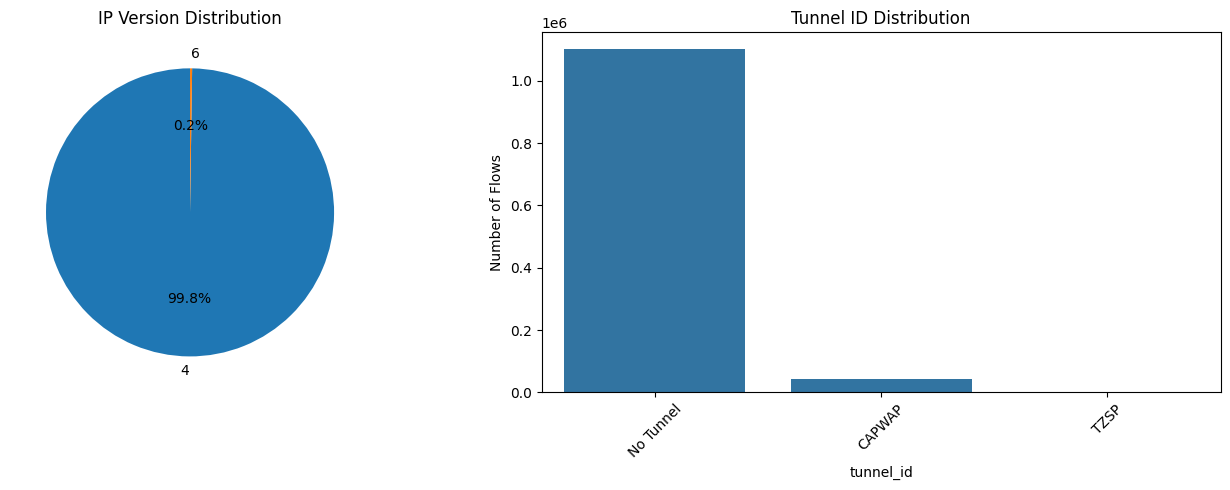

--- IP Version Counts ---
ip_version
4    1139580
6       2650
Name: count, dtype: int64

--- Tunnel ID Counts ---
tunnel_id
0    1100501
2      41713
3         16
Name: count, dtype: int64


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- IP Version Analysis ---
ip_version_dist = df['ip_version'].value_counts()
axes[0].pie(ip_version_dist, labels=ip_version_dist.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('IP Version Distribution')

# --- Tunnel ID Analysis ---
# Map tunnel IDs to human-readable names for the plot
tunnel_map = {0: 'No Tunnel', 1: 'GTP', 2: 'CAPWAP', 3: 'TZSP'}
tunnel_dist = df['tunnel_id'].map(tunnel_map).value_counts()
sns.barplot(x=tunnel_dist.index, y=tunnel_dist.values, ax=axes[1])
axes[1].set_title('Tunnel ID Distribution')
axes[1].set_ylabel('Number of Flows')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print detailed counts
print("--- IP Version Counts ---")
print(ip_version_dist)
print("\n--- Tunnel ID Counts ---")
print(df['tunnel_id'].value_counts())

**Observation:**
The analysis of the network layer provides two key insights into our dataset's environment:

1.  **IP Version:** The dataset is overwhelmingly composed of **IPv4 traffic (99.8%)**. The small presence of IPv6 traffic (0.2%) indicates that the network is not a pure legacy environment but has some interaction with modern IPv6-enabled services.

2.  **Tunneling:** More revealing is the distribution of tunnel types.
    *   While the vast majority of flows are standard non-tunneled internet traffic (`tunnel_id=0`), a significant portion (~3.7%) are identified as **CAPWAP (`tunnel_id=2`)** tunnels. CAPWAP (Control and Provisioning of Wireless Access Points) is a protocol used to manage enterprise or sophisticated home Wi-Fi networks. This strongly suggests that a substantial part of our data was captured from a **managed wireless network**.
    *   The presence of a few **TZSP (`tunnel_id=3`)** flows, a protocol for remote packet sniffing, hints at an even more complex capture setup.

**Key Takeaway:** Our dataset is not from a simple, single-host capture. It represents a mixed IPv4/IPv6 environment that includes traffic from a managed Wi-Fi infrastructure. This context is important for understanding the types of applications and traffic patterns we are likely to encounter in our analysis.

#### 2.3.3. The Protocol Landscape: TCP, UDP, and Others

Let's examine the distribution of the main transport protocols in our dataset. The `protocol` feature uses IANA protocol numbers, where `6` represents TCP and `17` represents UDP. Understanding this split is fundamental, as many of our features are protocol-dependent.

Transport Protocol Distribution:
           Flows Percentage
protocol                   
UDP      698,554      61.2%
TCP      443,676      38.8%


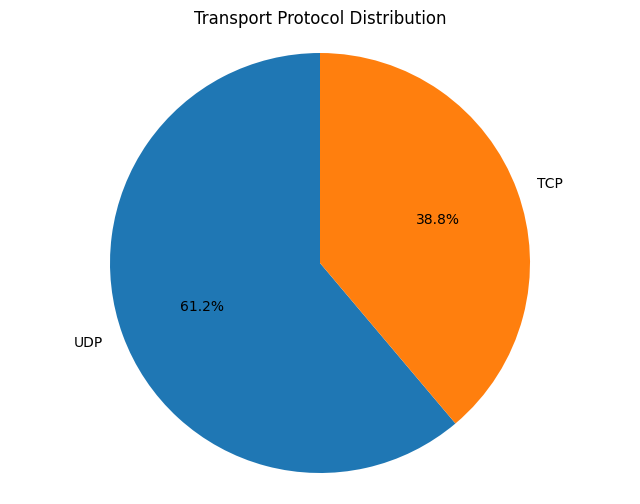

In [10]:
# Examine the protocol landscape in our data
protocol_dist = df['protocol'].value_counts()
# Note: We can add other common protocols to our map if needed
protocol_names = {6: 'TCP', 17: 'UDP', 1: 'ICMP', 58: 'ICMPv6'}

print("Transport Protocol Distribution:")
print("=" * 40)
# Create a DataFrame for a cleaner summary
protocol_summary = pd.DataFrame({
    'Flows': protocol_dist
})
protocol_summary['Percentage'] = (protocol_summary['Flows'] / len(df)) * 100
protocol_summary.index = protocol_summary.index.map(lambda p: protocol_names.get(p, f'Other ({p})'))
print(protocol_summary.to_string(formatters={'Flows': '{:,}'.format, 'Percentage': '{:.1f}%'.format}))


# Visualize the split
plt.figure(figsize=(8, 6))
# For the plot, let's group minor protocols into 'Other' to keep the pie chart clean
plot_dist = df['protocol'].map(lambda p: protocol_names.get(p) if p in [6, 17] else 'Other').value_counts()
plt.pie(plot_dist, labels=plot_dist.index, autopct='%1.1f%%', startangle=90)
plt.title('Transport Protocol Distribution')
plt.axis('equal')
plt.show()

**Observation:**
The dataset is primarily composed of UDP and TCP traffic, with UDP being the slight majority at **61.2%** of all flows.
- **UDP (User Datagram Protocol):** A connectionless and faster protocol, favored by real-time applications like streaming, gaming, and query-based protocols like DNS.
- **TCP (Transmission Control Protocol):** Known for its reliability and connection-oriented nature, used for applications like web browsing, file transfers, and email.

This distribution has profound implications for our feature space. For example, the 24 TCP-specific flag features (`_syn_packets`, `_ack_packets`, etc.) will, by design, be zero for the 61.2% of our dataset that is UDP-based. We will investigate this dependency next.

#### 2.3.4. Protocol-Dependent Features: The Case of TCP Flags

Our feature set contains 24 features related to TCP flags (`_syn_`, `_ack_`, `_fin_`, etc.). These flags are integral to TCP's state management but are non-existent in the UDP protocol. Let's verify this inherent structural dependency in our data.

In [11]:
# Identify TCP-specific features
tcp_flag_features = [col for col in df.columns if any(flag in col for flag in
                     ['_syn_', '_ack_', '_fin_', '_rst_', '_psh_', '_urg_', '_cwr_', '_ece_'])]

print(f"Investigating the {len(tcp_flag_features)} TCP flag features across protocols...")
print("=" * 50)

# Separate flows by protocol
tcp_flows = df[df['protocol'] == 6]
udp_flows = df[df['protocol'] == 17]

# Examine the total sum of TCP flag values in UDP flows
udp_flag_totals = udp_flows[tcp_flag_features].sum()

print(f"Total sum of all TCP flags in {len(udp_flows):,} UDP flows: {udp_flag_totals.sum()}")
if udp_flag_totals.sum() == 0:
    print("This confirms that TCP-specific features are always zero for UDP flows.")

Investigating the 24 TCP flag features across protocols...
Total sum of all TCP flags in 698,554 UDP flows: 0
This confirms that TCP-specific features are always zero for UDP flows.


**Analysis:**
This result confirms a fundamental protocol dependency: **61.2% of our dataset (all UDP flows) will have a value of zero for all 24 TCP flag features.** This is not missing data; it is a structural characteristic of the traffic that directly reflects protocol design. A machine learning model must learn to interpret these features conditionally, i.e., "if protocol is TCP, then analyze TCP flags; otherwise, their value is not informative." Tree-based models are particularly adept at learning such rules.

#### 2.3.5. Application-to-Protocol Mapping

Let's explicitly map our target applications to their transport protocols. This helps us understand if certain applications are "hard-wired" to a single protocol or if they can operate over both TCP and UDP.

In [12]:
# Map applications to their protocols
print("\nApplication-Protocol Relationships:")
print("=" * 40)

# Use crosstab to get a clean mapping.
# We'll look at the head() and tail() to see a sample of the 440 applications.
app_protocol_map = pd.crosstab(df['application_name'], df['protocol'].map(protocol_names))
print(app_protocol_map) # Display head and tail for a summary

# Check for applications that use both
apps_using_both = app_protocol_map[(app_protocol_map['TCP'] > 0) & (app_protocol_map['UDP'] > 0)]

if not apps_using_both.empty:
    print(f"\nWarning: Found {len(apps_using_both)} applications that were observed using both TCP and UDP.")
    print("Example applications using both protocols:")
    print(apps_using_both.head())
else:
    print("\nObservation: Each application in this dataset exclusively uses either TCP or UDP.")


Application-Protocol Relationships:
protocol           TCP   UDP
application_name            
AFP                  4     0
AJP                 79     0
AVAST               67     0
Alibaba            294    98
AmazonAWS          518  1095
...                ...   ...
WireGuard.NordVPN    0     8
Xiaomi              66     0
YandexCloud          0     4
Z3950                2     0
Zabbix              26     0

[440 rows x 2 columns]

Example applications using both protocols:
protocol            TCP    UDP
application_name              
Alibaba             294     98
AmazonAWS           518   1095
Apple               136     12
Azure               785   3127
BitTorrent        10396  42434


**Analysis:**
This analysis reveals a much more complex and realistic picture than a simple one-to-one mapping.

-   **Protocol Specialization:** The vast majority of the 440 identified applications are indeed tied exclusively to either TCP (like `AFP`, `Xiaomi`) or UDP (`WireGuard`, `YandexCloud`).
-   **Protocol Agnosticism:** Crucially, we found **41 applications that operate over both TCP and UDP**. A prime example is `BitTorrent`, which uses TCP for peer communication and control, but UDP for peer discovery and tracking (trackers). Similarly, large cloud ecosystems like `AmazonAWS` and `Azure` use both protocols extensively for their wide array of services.

**Key Takeaway:** This is a critical finding. The `protocol` feature is a powerful piece of information, but it is not a perfect predictor of the application. Many modern services and applications are not constrained to a single transport protocol. This means our model cannot simply learn a rule like "if protocol is UDP, then application is X." It must learn to distinguish applications based on their more subtle behavioral patterns, which reinforces the need for the rich statistical features we are preparing.

#### 2.3.6. Solving the Mystery of Missing Application Layer Features

We now return to the issue identified in our quality assessment: the high percentage of missing values in features like `client_fingerprint`, `server_fingerprint`, and `requested_server_name`. Our hypothesis is that this is **structural missingness**—the data isn't missing because of an error, but because it can only be generated for specific protocols.

Let's test this by examining which applications have non-null `client_fingerprint` values.

In [13]:
# Investigate which applications have non-null fingerprints
apps_with_fingerprints = df[df['client_fingerprint'].notna()]['application_name'].unique()

print(f"Found {len(apps_with_fingerprints)} application types WITH client fingerprints.")
print("Examples: ", list(apps_with_fingerprints))

print("\n" + "="*70 + "\n")

# Now, let's look at the other side: applications WITHOUT fingerprints
apps_without_fingerprints = df[df['client_fingerprint'].isnull()]['application_name'].unique()

print(f"Found {len(apps_without_fingerprints)} application types WITHOUT client fingerprints.")
print("Examples: ", list(apps_without_fingerprints))

Found 202 application types WITH client fingerprints.
Examples:  ['TLS.TikTok', 'TLS', 'TLS.Microsoft365', 'TLS.Google', 'TLS.Playstation', 'TLS.AppleiTunes', 'TLS.Microsoft', 'TLS.LLM', 'QUIC', 'TLS.WhatsAppFiles', 'TLS.WindowsUpdate', 'DHCP', 'QUIC.Facebook', 'TLS.MS_OneDrive', 'TLS.GoogleServices', 'QUIC.Google', 'TLS.ADS_Analytic_Track', 'TLS.Roblox', 'TLS.Teams', 'TLS.Xbox', 'TLS.FacebookMessenger', 'TLS.ElectronicArts', 'QUIC.Instagram', 'TLS.NetEaseGames', 'TLS.Amazon', 'TLS.Discord', 'TLS.Azure', 'TLS.DoH_DoT', 'TLS.Apple', 'QUIC.DoH_DoT', 'TLS.Cybersec', 'TLS.Slack', 'TLS.Facebook', 'IMAPS.GMail', 'TLS.KakaoTalk', 'TLS.FbookReelStory', 'QUIC.WhatsAppFiles', 'TLS.ApplePush', 'TLS.Blizzard', 'QUIC.Spotify', 'TLS.Spotify', 'TLS.EpicGames', 'TLS.Steam', 'TLS.GMail', 'TLS.PlayStore', 'TLS.Pinterest', 'TLS.YouTube', 'TLS.AdultContent', 'QUIC.LinkedIn', 'QUIC.YouTube', 'TLS.Mozilla', 'QUIC.ADS_Analytic_Track', 'QUIC.PlayStore', 'TLS.Telegram', 'TLS.Crashlytics', 'TLS.AppleSiri', 'TLS

**Analysis:**
This detailed analysis confirms our primary hypothesis but also reveals a crucial nuance. The applications fall mainly into two distinct groups:

1.  **Applications WITH Fingerprints:** These are **exclusively** applications that use protocols capable of providing them.
    -   **TLS/DTLS:** The vast majority are prefixed with `TLS.` or `DTLS.`, indicating they were identified over Transport Layer Security.
    -   **QUIC:** Google's QUIC protocol, which has encryption built-in, also generates fingerprints.
    -   **SSH & DHCP:** These protocols have their own fingerprinting mechanisms that nDPI also extracts.

2.  **Applications WITHOUT Fingerprints:** This group consists of applications that use protocols with no standardized fingerprinting mechanism. This includes:
    -   **UDP-based protocols:** `STUN`, `NTP`, `NetBIOS`, `Spotify` (for its real-time data transfer).
    -   **Unencrypted protocols:** `DNS`, `BitTorrent`, `SSDP`.
    -   **Proprietary protocols:** `RDP` (standard RDP, not over TLS).
    -   **Unidentified traffic:** `Unknown`.

**The Overlap—A Deeper Insight:** The most interesting finding is the **19 applications that appear in both lists**, such as `TLS` and `SSH`. This is not a contradiction. It demonstrates that for a given application, a fingerprint can only be generated if the **entire necessary handshake is present and valid** within the packets captured for that specific flow. If a flow is labeled "TLS" but its initial `ClientHello` packet was missed by the capture (or ignored by NFStream as it is not the first fragment), nDPI can still make a confident guess based on port and behavior, but it cannot generate a fingerprint. This results in some "TLS" flows having a fingerprint and others not.

This confirms that the missingness is not a data error but is tied directly to the availability of specific handshake packets within a given flow. Including any of these application-layer features (`_fingerprint`, `requested_server_name`, etc.) directly in a model would create a powerful **data leakage** path. The model would learn spurious correlations related to capture conditions (*"if fingerprint is not null, it must be TLS/QUIC/SSH,"*) rather than learning anything about the underlying behavioral patterns of the traffic itself. This is a classic trap that leads to models that perform well in the lab but fail in the real world. Therefore, these features must be excluded from our general-purpose classifier.

#### 2.3.7. Label Quality Analysis: Guesses and Confidence

Not all application labels assigned by a DPI engine are created equal. Sometimes, the engine makes a high-confidence identification based on definitive protocol handshakes. Other times, if the necessary packets are missing, it may fall back to making a lower-confidence "guess" based on heuristics like port numbers.

Before we trust our target variable (`application_name`), we must investigate the quality of the labels. We will analyze two key features:
-   `application_is_guessed`: A boolean flag indicating if the label was a guess.
-   `application_confidence`: A numerical score from nDPI indicating the method used for detection.

This analysis will help us decide if we should filter out low-confidence labels to ensure our model is trained on the most reliable ground truth possible.

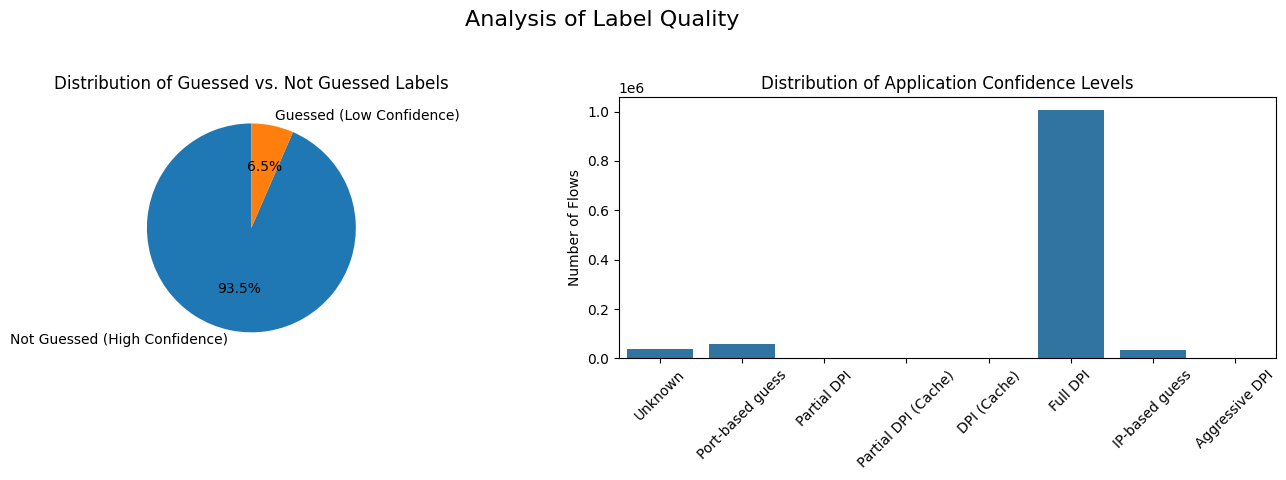

--- 'application_is_guessed' Counts ---
application_is_guessed
0    1067750
1      74480
Name: count, dtype: int64

--- 'application_confidence' Counts ---
application_confidence
0      38417
1      56810
3       3824
4        979
5       1126
6    1007412
7      33661
8          1
Name: count, dtype: int64


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Create a figure with two subplots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analysis of Label Quality', fontsize=16)

# --- 1. application_is_guessed Analysis ---
guessed_dist = df['application_is_guessed'].value_counts()
guessed_labels = {0: 'Not Guessed (High Confidence)', 1: 'Guessed (Low Confidence)'}
axes[0].pie(guessed_dist, labels=[guessed_labels.get(i) for i in guessed_dist.index], autopct='%1.1f%%', startangle=90)
axes[0].set_title('Distribution of Guessed vs. Not Guessed Labels')

# --- 2. application_confidence Analysis ---
confidence_dist = df['application_confidence'].value_counts().sort_index()
# Map confidence levels to descriptive names for clarity
confidence_map = {
    0: 'Unknown', 1: 'Port-based guess', 2: 'nBPF', 3: 'Partial DPI',
    4: 'Partial DPI (Cache)', 5: 'DPI (Cache)', 6: 'Full DPI',
    7: 'IP-based guess', 8: 'Aggressive DPI', 9: 'Custom Rule'
}
confidence_labels = [confidence_map.get(i, f'Level {i}') for i in confidence_dist.index]
sns.barplot(x=confidence_labels, y=confidence_dist.values, ax=axes[1])
axes[1].set_title('Distribution of Application Confidence Levels')
axes[1].set_ylabel('Number of Flows')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()

# --- Print detailed counts for reference ---
print("--- 'application_is_guessed' Counts ---")
print(guessed_dist)
print("\n--- 'application_confidence' Counts ---")
print(confidence_dist)

**Analysis:**
The analysis provides a clear picture of our label quality.

1.  **Guessed Labels:** The `application_is_guessed` plot shows that the vast majority of our labels (**93.5%**) are considered high-confidence (`Not Guessed`). However, a non-trivial **6.5%** of labels were low-confidence guesses made by the DPI engine when a definitive identification was not possible.

2.  **Confidence Levels:**

    * nDPI defines the following confidence levels of protocol detection (0-9):
        - 0: Unknown classification
        - 1: Classification based only on L4 ports
        - 2: PF_RING nBPF custom protocol
        - 3: Based on partial/incomplete DPI information
        - 4: Based on LRU cache with partial DPI info
        - 5: Based on LRU cache (session correlation)
        - 6: Full deep packet inspection
        - 7: Classification based only on IP addresses
        - 8: Aggressive DPI (possible false positive)
        - 9: Matching custom rules

    * The `application_confidence` bar chart breaks this down further.
        *   The overwhelming majority of flows (**1,007,412**) were identified with `Full DPI` (`confidence=6`), which is the highest level of assurance.
        *   The largest groups of low-confidence labels come from `Port-based guess` (`confidence=1`) and `IP-based guess` (`confidence=7`). These are weak indicators that simply map a well-known port (e.g., port 53 -> DNS) or IP address to a service, without inspecting the traffic content.
        *   The 38,417 flows with `Unknown` confidence (`confidence=0`) correspond directly to the unlabeled flows we identified in Section 1.2.2.

**Key Takeaway and Strategy:**
For a supervised learning task, the quality of the labels is paramount. To build the most reliable and accurate classifier possible, we should train it only on data that we can trust. Therefore, in our data cleaning phase, we will filter our dataset to keep **only the flows identified with the highest confidence**.
<!-- This means we will retain flows where `application_confidence == 6` (Full DPI). This action will remove the "guessed" and "unknown" labels, ensuring our model learns from the most accurate ground truth available. -->

#### 2.3.8. Analyzing Flow Characteristics

Now that we have analyzed the protocol and label-based features, let's turn our attention to the core behavioral characteristics of the flows themselves. We will investigate three key metrics: duration, packet count, and maximum packet size. This analysis will help us identify normal and anomalous patterns, such as network scans or incomplete connections, which we may want to exclude from our training data.

##### Flow Duration

First, we'll analyze the distribution of `bidirectional_duration_ms`. A high number of zero-duration flows (**one packet flows**) can be an indicator of network scanning activity or connection attempts that were immediately terminated.

--- Analysis of Flow Duration (bidirectional_duration_ms) ---
Number of zero-duration flows: 62,540
Percentage of zero-duration flows: 5.48%


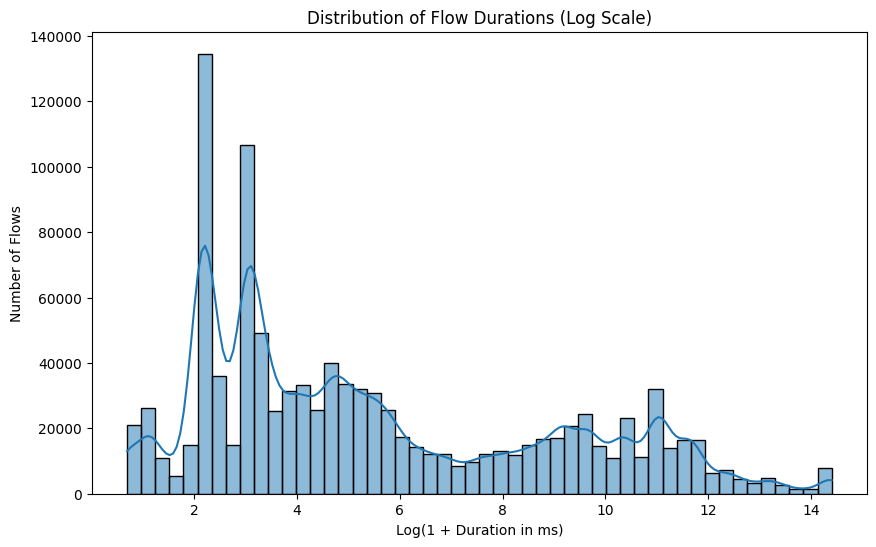


--- Descriptive Statistics for Flow Duration ---
count    1,142,230.00
mean        31,881.17
std        165,793.10
min              0.00
25%             11.00
50%             69.00
75%          3,099.00
max      1,799,999.00
Name: bidirectional_duration_ms, dtype: object


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Analyze Flow Duration ---
print("--- Analysis of Flow Duration (bidirectional_duration_ms) ---")

# Calculate the number and percentage of zero-duration flows
zero_duration_flows = df[df['bidirectional_duration_ms'] == 0]
percentage_zero_duration = (len(zero_duration_flows) / len(df)) * 100

print(f"Number of zero-duration flows: {len(zero_duration_flows):,}")
print(f"Percentage of zero-duration flows: {percentage_zero_duration:.2f}%")

# It's often more insightful to see the distribution on a log scale due to the long tail
# We will plot a histogram of the log of the duration for non-zero duration flows
plt.figure(figsize=(10, 6))
# Adding a small constant (1) to avoid log(0)
log_durations = np.log1p(df[df['bidirectional_duration_ms'] > 0]['bidirectional_duration_ms'])
sns.histplot(log_durations, bins=50, kde=True)
plt.title('Distribution of Flow Durations (Log Scale)')
plt.xlabel('Log(1 + Duration in ms)')
plt.ylabel('Number of Flows')
plt.show()

# Also, let's look at the basic statistics of the duration
print("\n--- Descriptive Statistics for Flow Duration ---")
print(df['bidirectional_duration_ms'].describe().apply("{:,.2f}".format))

**Analysis:**
The analysis of flow duration reveals two important characteristics of the dataset.

1.  **Zero-Duration Flows:** A significant portion of the data, **5.5% (over 62,000 flows)**, have a duration of zero milliseconds. These typically represent single-packet communications (like DNS queries without a response in the capture) or connection attempts that were instantly rejected. These flows contain minimal behavioral information and are prime candidates for removal during our data cleaning phase.

2.  **Long-Tail Distribution:** For flows with a non-zero duration, the descriptive statistics and the histogram show a classic "long-tail" distribution common in network traffic.
    -   **Median (50%):** 69 ms. This means half of all flows are extremely short, lasting less than a tenth of a second.
    -   **Mean:** 31,881 ms (~32 seconds). The mean is dramatically higher than the median, pulled up by a small number of very long-lived flows.
    -   **Max:** 1,799,999 ms (~30 minutes). The longest flows last for the full `active_timeout` of the capture, representing continuous sessions.

**Key Takeaway:** The dataset contains a large number of very short or instantaneous flows. For building a behavioral classifier, these short-lived flows often represent noise rather than meaningful communication sessions. We will likely need to filter these out to ensure our model is trained on flows with sufficient information to make a robust classification.

##### Flow Packet Count

Next, we will analyze the distribution of `bidirectional_packets`. This is strongly correlated with duration and gives us another way to identify flows that may be too short to contain meaningful behavioral patterns. Flows with only one or two packets are often just connection attempts (e.g., a single TCP SYN), scans, or unidirectional "beacon" traffic, which are not representative of a full application session.

--- Analysis of Flow Packet Count (bidirectional_packets) ---
Number of flows with <= 2 packets: 515,933
Percentage of flows with <= 2 packets: 45.17%


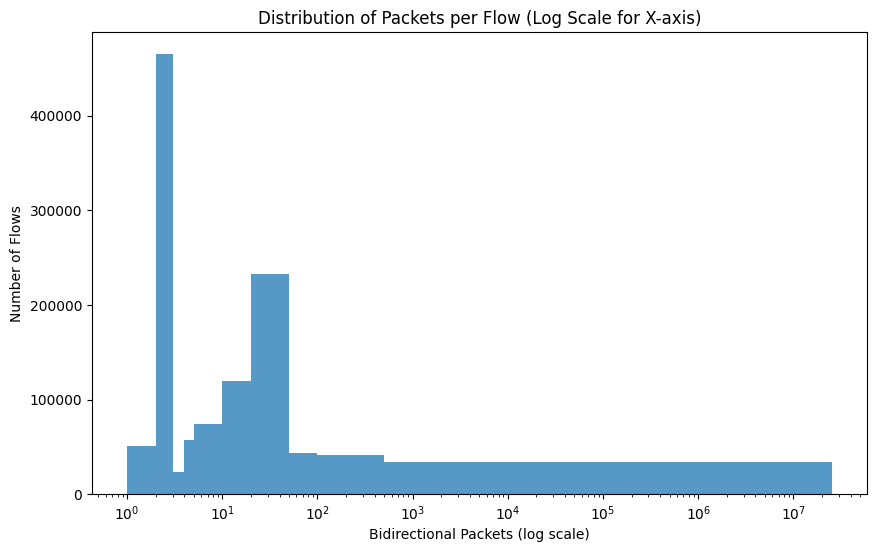


--- Descriptive Statistics for Flow Packet Count ---
count     1,142,230.00
mean            780.15
std          57,879.47
min               1.00
25%               2.00
50%               4.00
75%              24.00
max      25,282,526.00
Name: bidirectional_packets, dtype: object


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Analyze Flow Packet Count ---
print("--- Analysis of Flow Packet Count (bidirectional_packets) ---")

# Calculate the number and percentage of low-packet-count flows
low_packet_flows_count = df[df['bidirectional_packets'] <= 2].shape[0]
percentage_low_packet = (low_packet_flows_count / len(df)) * 100

print(f"Number of flows with <= 2 packets: {low_packet_flows_count:,}")
print(f"Percentage of flows with <= 2 packets: {percentage_low_packet:.2f}%")

# Plot a histogram of the log of packet counts for a better view of the distribution
plt.figure(figsize=(10, 6))
# We will use a log scale for the y-axis (number of flows) to see the distribution of low-packet flows better
packet_counts = df['bidirectional_packets']
# Bins can be set explicitly for better granularity at the low end
bins = [0, 1, 2, 3, 4, 5, 10, 20, 50, 100, 500, packet_counts.max()]
sns.histplot(data=df, x='bidirectional_packets', bins=bins)
plt.xscale('log') # Use a log scale on the x-axis to handle the long tail
plt.title('Distribution of Packets per Flow (Log Scale for X-axis)')
plt.xlabel('Bidirectional Packets (log scale)')
plt.ylabel('Number of Flows')
plt.show()

# Also, let's look at the basic statistics of the packet counts
print("\n--- Descriptive Statistics for Flow Packet Count ---")
print(df['bidirectional_packets'].describe().apply("{:,.2f}".format))

**Analysis:**
The analysis of packet counts reveals a critical characteristic of our dataset: it is dominated by extremely short flows.

1.  **High Volume of Short Flows:** A staggering **45.2% of all flows in the dataset consist of just one or two packets**. This is a massive portion of the data.
2.  **Low Median:** The descriptive statistics confirm this. The median (`50%`) packet count is only **4**. This means that half of all flows in the dataset have four or fewer packets.
3.  **Long-Tail Distribution:** As with duration, the mean is skewed extremely high by a small number of massive flows (one flow has over 25 million packets), which is clearly visible in the histogram's long tail.

**Key Takeaway and Strategy:**
This finding is paramount. Nearly half our dataset consists of flows that are not complete application sessions. However, the problem extends beyond just 1- or 2-packet flows.

-   For **TCP-based** traffic (like most TLS), a 3-packet TCP handshake is required *before* the encrypted handshake even begins, which itself can take another 4-8 packets.
-   For **QUIC** traffic, the transport and cryptographic handshakes are combined but still typically require at least 3-4 packets to establish a secure session.

In either case, flows with fewer than 5-8 packets often represent little more than a connection setup or handshake attempt, with no actual application data being transferred. To build a robust classifier based on *behavior*, we must train it on flows that exhibit that behavior.

<!-- This strongly justifies an aggressive filtering strategy. In our upcoming data cleaning phase, we will establish a minimum packet count threshold of **10 packets**. This is a robust choice that comfortably clears the handshake phase for both major secure protocols and ensures our model learns from meaningful communication sessions, not just connection artifacts. -->

##### Maximum Packet Size

Our final check is to analyze the `bidirectional_max_ps` (maximum packet size). As discussed in our section on NIC offloading, packets captured *after* hardware-level reassembly (LRO/GRO) can appear to be much larger than what the network's Maximum Transmission Unit (MTU) would permit in a single frame.

A standard Ethernet frame has a maximum payload size of 1500 bytes. This payload is the IP packet. Since our dataset was generated with `accounting_mode=2` (Transport Layer), which strips the IP header (typically 20 bytes for IPv4), the maximum possible packet size we should observe is **1480 bytes** (`1500 - 20`). Any value significantly larger than this would indicate that the capture was subject to receive offloading, which would fundamentally change the statistical properties of our features.

Let's examine the distribution of `bidirectional_max_ps` to validate the integrity of our packet size features.

--- Analysis of Maximum Packet Size (bidirectional_max_ps) ---
Descriptive Statistics for Maximum Packet Size:
count    1,142,230.00
mean           595.35
std            590.66
min              8.00
25%            103.00
50%            228.00
75%          1,260.00
max          1,480.00
Name: bidirectional_max_ps, dtype: object

Number of flows with max_ps > 1514 bytes: 0
Percentage of flows with max_ps > 1514 bytes: 0.0000%


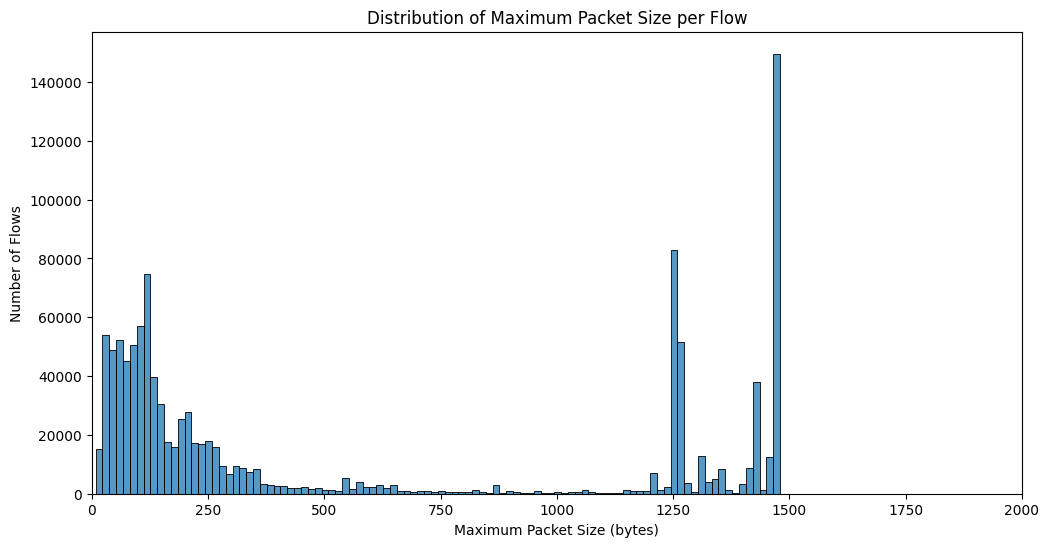

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Analyze Maximum Packet Size ---
print("--- Analysis of Maximum Packet Size (bidirectional_max_ps) ---")

# Describe the feature to see min, max, mean, etc.
print("Descriptive Statistics for Maximum Packet Size:")
print(df['bidirectional_max_ps'].describe().apply("{:,.2f}".format))

# Count how many flows have a max packet size larger than a typical MTU-based size
# We'll use a threshold of 1514 (a full Ethernet frame) as a generous upper bound.
large_packets_count = df[df['bidirectional_max_ps'] > 1514].shape[0]
percentage_large_packets = (large_packets_count / len(df)) * 100

print(f"\nNumber of flows with max_ps > 1514 bytes: {large_packets_count:,}")
print(f"Percentage of flows with max_ps > 1514 bytes: {percentage_large_packets:.4f}%")

# Plot a histogram to visualize the distribution
plt.figure(figsize=(12, 6))
sns.histplot(df['bidirectional_max_ps'], bins=100)
plt.title('Distribution of Maximum Packet Size per Flow')
plt.xlabel('Maximum Packet Size (bytes)')
plt.ylabel('Number of Flows')
# Set a reasonable x-limit to zoom in on the relevant range and see if there are outliers
plt.xlim(0, 2000)
plt.show()

**Analysis:**
The results from this analysis provide a definitive confirmation of our data's integrity.

1.  **No "Super Packets":** The `max` value in the descriptive statistics is **1,480 bytes**. This is perfectly aligned with the theoretical maximum size for a TCP or UDP segment inside a standard 1500-byte IP packet after the 20-byte IPv4 header has been removed.
2.  **Zero Outliers:** The check for flows with a maximum packet size greater than a generous 1514-byte threshold found **zero** such flows.

**Key Takeaway:** This result confirms that our dataset was captured *before* any NIC-level receive offloading (LRO/GRO) could occur. The packet size features are a true representation of the segments as they were prepared by the transport layer. This is a critical validation, as it ensures that our model will be trained on consistent and predictable feature distributions, free from the confounding variable of hardware-specific optimizations.

----

### 3.4. Data Cleaning and Feature Selection

Our exploratory data analysis has given us a deep understanding of the dataset's structure, dependencies, and potential quality issues. We will now use these insights to perform the most critical step before modeling: **cleaning the data and selecting our final features**. This process ensures we build our models using only the most reliable, informative, and generalizable data.

#### 3.4.1. Row Filtering Strategy (what data to keep)

We will apply a chain of filters to the dataset, keeping only the rows that meet our stringent quality criteria.
A flow must meet **all** of the following criteria to be kept:

<!-- 1.  **Must Not Be Guessed:**
    *   **Decision:** Keep only rows where `application_is_guessed == 0`.
    *   **Justification:** This is our first line of defense against low-quality labels. It removes any flow where the DPI engine had to fall back on weak heuristics.

2.  **Must Be Reliably Identified (stricter):**
    *   **Decision:** From the remaining flows, keep only rows where `application_confidence == 6` (Full DPI).
    *   **Justification:** This second, stricter filter ensures we are left with only the "gold standard" labels, identified with the highest possible assurance from deep packet inspection.

3.  **Must Have a Known Label:**
    *   **Decision:** Drop all rows where `application_name == 'Unknown'`.
    *   **Justification:** This explicitly removes any remaining unlabeled data. As you noted, this also removes the corresponding `"Unspecified"` categories.

4.  **Must Contain Sufficient Behavioral Data:**
    *   **Decision:** Keep only rows where `bidirectional_packets >= 10`.
    *   **Justification:** This robust threshold ensures we filter out connection noise and incomplete handshakes, forcing the models to learn from meaningful application sessions. -->

1.  **Must Not Be Guessed (`application_is_guessed == 0`):** We will remove flows where the DPI engine had to fall back on weak heuristics.
2.  **Must Be Reliably Identified (`application_confidence == 6`):** We will enforce the strictest confidence level to ensure we are training on the most accurate "gold standard" labels.
3.  **Must Have a Known Label (`application_name != 'Unknown'`):** We will remove all flows that could not be identified. This filter has the important side effect of also removing all corresponding flows where `application_category_name` is `"Unspecified"`.
4.  **Must Contain Sufficient Behavioral Data (`bidirectional_packets >= 10`):** We will remove "micro-flows" to ensure our model learns from meaningful sessions. This robust threshold implicitly handles the removal of zero-duration flows, as any flow with 10 packets will, by necessity, have a non-zero duration.

We will show the number of flows remaining after each step to illustrate the impact of our decisions.

In [18]:
import pandas as pd

# Assume 'df' is the full DataFrame loaded in the previous sections.
print(f"Original dataset shape: {df.shape}")

# --- Step 1: Keep only flows that were not guessed ---
df_clean = df[df['application_is_guessed'] == 0].copy()
print(f"Shape after removing 'guessed' flows: {df_clean.shape}")

# --- Step 2: Keep only flows with the highest confidence level ---
df_clean = df_clean[df_clean['application_confidence'] == 6].copy()
print(f"Shape after keeping only confidence level 6: {df_clean.shape}")

# --- Step 3: Remove flows labeled as 'Unknown' ---
# This also removes the corresponding 'Unspecified' category
df_clean = df_clean[df_clean['application_name'] != 'Unknown'].copy()
print(f"Shape after removing 'Unknown' applications: {df_clean.shape}")

# --- Step 4: Keep only flows with a minimum number of packets ---
# This also removes zero-duration flows
MIN_PACKETS = 10
df_clean = df_clean[df_clean['bidirectional_packets'] >= MIN_PACKETS].copy()
print(f"Shape after keeping flows with >= {MIN_PACKETS} packets: {df_clean.shape}")

# --- Final Tally ---
percentage_remaining = (len(df_clean) / len(df)) * 100
print("\n--- Filtering Summary ---")
print(f"Original number of flows: {len(df):,}")
print(f"Number of flows remaining after cleaning: {len(df_clean):,}")
print(f"Percentage of original data remaining: {percentage_remaining:.2f}%")

Original dataset shape: (1142230, 89)
Shape after removing 'guessed' flows: (1067750, 89)
Shape after keeping only confidence level 6: (1007412, 89)
Shape after removing 'Unknown' applications: (1007412, 89)
Shape after keeping flows with >= 10 packets: (429597, 89)

--- Filtering Summary ---
Original number of flows: 1,142,230
Number of flows remaining after cleaning: 429,597
Percentage of original data remaining: 37.61%


**Observation:**
The filtering process has a significant impact, reducing our dataset to **37.6%** of its original size. This is a crucial and beneficial step. We have deliberately removed over 60% of the data corresponding to low-confidence labels, unlabeled traffic, and network "noise." The remaining ~430,000 flows represent a high-quality, reliable dataset that is now suitable for training a robust classifier. This aggressive filtering is a feature, not a bug, of a rigorous data preparation pipeline.

#### 3.4.2. Re-checking Data Properties

A key principle of rigorous data preparation is that it is often an **iterative, cyclic process**, not a linear one. The act of filtering rows can change the statistical properties of the remaining columns. Features that previously had some variance might become constant after a large number of specific rows are removed.

Therefore, before moving to our final feature selection, it is a crucial sanity check to re-run the analysis. For this tutorial, we re-run only our zero-variance analysis on the newly cleaned `df_clean` DataFrame. This ensures we do not carry any "newly constant" features into our final model.

In [19]:
# Re-run the check for constant features on the cleaned DataFrame
print("--- Re-checking for constant features on the filtered data (df_clean) ---")
constant_features_after_cleaning = [col for col in df_clean.columns if df_clean[col].nunique() <= 1]

if len(constant_features_after_cleaning) > 0:
    print(f"\nFound {len(constant_features_after_cleaning)} constant features in the cleaned data:")
    for feature in constant_features_after_cleaning:
        print(f"  - {feature}")
else:
    print("\nConstant Feature Check: No new constant features found.")

# We can find the *new* constants by taking the set difference from our first check
initial_constants = {'vlan_id', 'dst2src_urg_packets'} # From our first run
new_constants = set(constant_features_after_cleaning) - initial_constants
if new_constants:
    print("\nNewly identified constant features after filtering:")
    for feature in new_constants:
        print(f"  - {feature}")

--- Re-checking for constant features on the filtered data (df_clean) ---

Found 6 constant features in the cleaned data:
  - vlan_id
  - bidirectional_urg_packets
  - src2dst_urg_packets
  - dst2src_urg_packets
  - application_is_guessed
  - application_confidence

Newly identified constant features after filtering:
  - src2dst_urg_packets
  - application_confidence
  - application_is_guessed
  - bidirectional_urg_packets


**Observation:** Our hypothesis was correct. The re-check reveals four **newly constant features**: `bidirectional_urg_packets`, `src2dst_urg_packets`, `application_is_guessed` and `application_confidence`.

This is a powerful insight. It tells us that the very few flows that *did* contain URG packets in the `src2dst` direction were part of the data we removed during our filtering (e.g., they were likely short-lived flows with fewer than 10 packets or had low-confidence labels). Once these flows were removed, the remaining `_urg_packets` features lost all their variance. Additionally, as we removed all the flows whose `application_confidence` was other than 6, this feature along with the `application_is_guessed` indicator have become constant.

**Key Takeaway:** This perfectly illustrates the iterative nature of data cleaning. It is a crucial best practice to re-evaluate your data's properties after any significant filtering or transformation step. We will now add these newly identified constant features to our list of columns to be dropped in the final feature selection phase.

#### 3.4.3. Column Dropping Strategy (Feature Selection)

After filtering the rows, we will select the columns that will form our feature matrix `X`. The guiding principle is to **exclude any feature that is not a generalizable, behavioral characteristic of the flow or could lead to data leakage.**

<!-- #### **Columns to EXCLUDE from the feature set `X`:** -->

<!-- 1.  **All Identifiers and Metadata:**
    *   **Columns:** `id`, `expiration_id`, `src_ip`, `dst_ip`, `src_mac`, `dst_mac`, `src_oui`, `dst_oui`, `src_port`, `dst_port`.
    *   **Justification:** These are identifiers for a specific session, host, or piece of hardware. Including them would cause the model to memorize the capture environment instead of learning general patterns (e.g., "traffic from this IP is always X"). This is a classic form of data leakage. We will, however, keep `protocol` as it is a fundamental behavioral attribute.

2.  **Absolute Timestamps:**
    *   **Columns:** `bidirectional_first_seen_ms`, `bidirectional_last_seen_ms`, and their `src2dst`/`dst2src` counterparts.
    *   **Justification:** These are absolute "time-of-day" timestamps from when the capture was taken. They do not generalize to traffic captured at other times. We will keep the relative `_duration_ms` features, which are generalizable.

3.  **All Application Layer and Fingerprint Features:**
    *   **Columns:** `requested_server_name`, `client_fingerprint`, `server_fingerprint`, `user_agent`, `content_type`.
    *   **Justification:** These features suffer from high structural missingness and are a major source of data leakage. A model could simply learn "if port is 6 and if fingerprint exists, it is TLS" without analyzing any other behavior.

4.  **Label Quality and Target Columns:**
    *   **Columns:** `application_is_guessed`, `application_confidence`, `application_name`, `application_category_name`.
    *   **Justification:** These are either metadata about the label's quality or the labels themselves (`y`). `application_is_guessed` and `application_confidence` served their role. Now there is no more need for them. As `application_name` and `application_category_name` are our target labels, they cannot be used as input features (`X`).

5.  **Constant (Zero-Variance) Features:**
    *   **Columns:** `vlan_id`, `dst2src_urg_packets`.
    *   **Justification:** These columns have no variance and thus provide no information to the model. -->

#### **Columns to EXCLUDE:**

1.  **Identifiers and Metadata:** `id`, `expiration_id`, `src_ip`, `dst_ip`, `src_mac`, `dst_mac`, `src_oui`, `dst_oui`, `src_port`, and `dst_port`. These are identifiers for a specific session, host, or piece of hardware. Including them would cause the model to memorize the capture environment instead of learning general patterns (e.g., "traffic from this IP is always X"). This is a classic form of data leakage. We will, however, keep `protocol` as it is a fundamental behavioral attribute.

3.  **Absolute Timestamps:** `bidirectional_first_seen_ms`, `bidirectional_last_seen_ms`, and their `src2dst`/`dst2src` counterparts. These are absolute "time-of-day" timestamps from when the capture was taken. They do not generalize to traffic captured at other times. We will keep the relative `_duration_ms` features, which are generalizable.

4.  **Application Layer and Fingerprint Features:** `requested_server_name`, `client_fingerprint`, `server_fingerprint`, `user_agent`, and `content_type`. These features suffer from high structural missingness and are a major source of data leakage. A model could simply learn "if port is 6 and if fingerprint exists, it is TLS" without analyzing any other behavior.

5.  **Label Quality and Target Columns:** `application_is_guessed`, `application_confidence`, `application_name`, and `application_category_name`. These are either metadata about the label's quality or the labels themselves (`y`). `application_is_guessed` and `application_confidence` served their role in ensuring high-quality labels. As `application_name` and `application_category_name` are our target labels, they cannot be used as input features (`X`).

6.  **Constant (Zero-Variance) Features:** `vlan_id`, `bidirectional_urg_packets`, `src2dst_urg_packets`, and `dst2src_urg_packets`. These columns have no variance and thus provide no information to the model.

<!-- #### **Columns to INCLUDE in the feature set `X`:**

This leaves us with the core behavioral and statistical features that are generalizable and robust:
-   `protocol`,
-   All `_duration_ms` features,
-   All `_packets` and `_bytes` volume features,
-   All _Packet Size Statistics_ (`_ps` features),
-   All _Inter Arrival Time Statistics_ (`_piat` features),
-   All non-constant _TCP Protocol Flag Counters_,
-   All `splt_` sequence features. -->

<!-- #### **Columns to INCLUDE:**
This leaves us with the core behavioral and statistical features: `protocol`, all `_duration_ms` features, all `_packets` and `_bytes` features, all packet size `_ps` and inter-arrival time `_piat` statistics, all non-constant TCP flag counters, and the `splt_*` sequence features. -->

<!-- You may have noticed that the `splt_*` features were included in the list above. They require a different modeling approach than the other statistical features. Therefore, we will now split our cleaned data into two specialized datasets to support our different experimental goals:

1.  **A Statistical Dataset:** For our primary model bake-off, we will **exclude** the list-based `splt_*` features to create a classic, flat feature matrix.
2.  **A Sequence Dataset:** For a dedicated advanced experiment, we will create a dataset containing **only** the `splt_*` features and the labels.

This separation allows for a clean and direct comparison of models built on statistical summaries versus those built on raw sequence data. -->

In [20]:
import numpy as np
import os

# --- Define columns to drop for the statistical dataset ---
# This list is based on our analysis in the preceding sections.
columns_to_drop_for_statistical = [
    # Identifiers and Metadata (excluding 'protocol' which is a feature)
    'id', 'expiration_id', 'src_ip', 'dst_ip', 'src_mac', 'dst_mac',
    'src_oui', 'dst_oui', 'src_port', 'dst_port', 'ip_version', 'tunnel_id',

    # Constant (Zero-Variance) Features
    'vlan_id', 'bidirectional_urg_packets', 'src2dst_urg_packets', 'dst2src_urg_packets',

    # Absolute Timestamps
    'bidirectional_first_seen_ms', 'bidirectional_last_seen_ms',
    'src2dst_first_seen_ms', 'src2dst_last_seen_ms',
    'dst2src_first_seen_ms', 'dst2src_last_seen_ms',

    # Leaky Application Layer Features
    'requested_server_name', 'client_fingerprint', 'server_fingerprint',
    'user_agent', 'content_type',

    # Label Quality Metadata (already used for filtering)
    'application_is_guessed', 'application_confidence',
]

# --- Create the Statistical Dataset ---
df_clean = df_clean.drop(columns=columns_to_drop_for_statistical)
print(f"Statistical dataset shape: {df_clean.shape}")
print(f"Number of features: {len(df_clean.columns) - 2}") # Subtract the two label columns

Statistical dataset shape: (429597, 60)
Number of features: 58


**Observation:** The feature selection process has been successfully executed. This leaves us with the core behavioral and statistical features: `protocol`, all `_duration_ms` features, all `_packets` and `_bytes` features, all packet size `_ps` and inter-arrival time `_piat` statistics, all non-constant TCP flag counters, and the `splt_*` sequence features. Our master `df_clean` DataFrame now contains **58 generalizable, behavioral features** and 2 label columns.

<!-- This is our ML-ready dataset for the main classification tasks. -->

----

### 3.5. Target Variable Analysis

With our feature matrix `X` finalized, we now turn our attention to what we are trying to predict: the **target variables** `y`. Our dataset provides labels at two levels of granularity, allowing for two distinct classification tasks:
*   **Coarse-grained classification:** Predicting the general application category (e.g., SocialNetwork, Media).
*   **Fine-grained classification:** Predicting the specific application name (e.g., TLS.TikTok, QUIC.YouTube).

Understanding the distribution of these targets is crucial, as it reveals the inherent challenges of the classification problem, particularly class imbalance.

In [21]:
# Create target variables for both classification granularities
y_coarse = df_clean['application_category_name'].copy()
y_fine = df_clean['application_name'].copy()

print(f"Target Variables Created:")
print(f"Coarse-grained targets (y_coarse): {y_coarse.shape}, {y_coarse.nunique()} unique classes")
print(f"Fine-grained targets (y_fine): {y_fine.shape}, {y_fine.nunique()} unique classes")

Target Variables Created:
Coarse-grained targets (y_coarse): (429597,), 28 unique classes
Fine-grained targets (y_fine): (429597,), 337 unique classes


#### 3.5.1. Distribution of Application Categories (Coarse-grained Target)

Let's analyze the distribution of the general application categories.

Application Category Distribution:
                            Flows Percentage
application_category_name                   
Web                       203,123     17.78%
SocialNetwork              39,138      3.43%
Collaborative              32,087      2.81%
Network                    29,042      2.54%
Game                       23,987      2.10%
Advertisement              18,255      1.60%
Media                      15,752      1.38%
SoftwareUpdate             12,345      1.08%
Music                      10,128      0.89%
Download                    9,923      0.87%
Cloud                       5,287      0.46%
RemoteAccess                4,961      0.43%
Chat                        4,249      0.37%
Video                       3,487      0.31%
Email                       3,059      0.27%
VPN                         2,518      0.22%
VoIP                        2,364      0.21%
Streaming                   2,339      0.20%
ConnCheck                   1,737      0.15%
Cybersecurity       

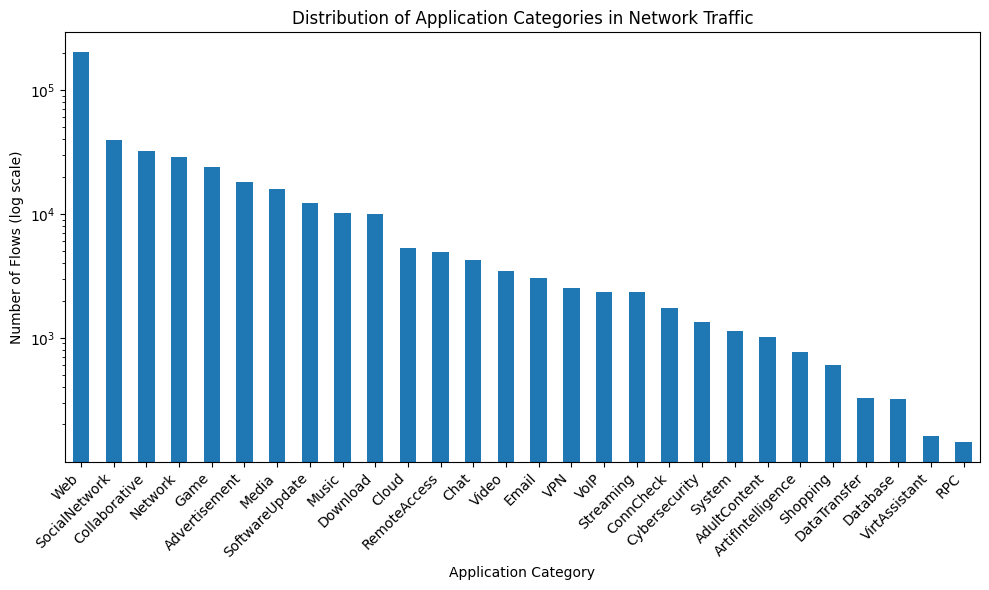

In [22]:
# Analyze the coarse-grained target: application categories
print("Application Category Distribution:")
print("=" * 50)
category_counts = y_coarse.value_counts()
category_percentages = (category_counts / len(df)) * 100

# Create a DataFrame for nice printing
category_dist_df = pd.DataFrame({
    'Flows': category_counts,
    'Percentage': category_percentages
})
print(category_dist_df.to_string(formatters={'Flows': '{:,}'.format, 'Percentage': '{:.2f}%'.format}))

# Visualize to better understand the scale of imbalance
plt.figure(figsize=(10, 6))
category_counts.plot(kind='bar')
plt.title('Distribution of Application Categories in Network Traffic')
plt.xlabel('Application Category')
plt.ylabel('Number of Flows (log scale)')
plt.yscale('log')  # Log scale is essential to see the rare classes
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Analysis (Coarse-grained):**
The distribution of our 28 application categories reveals the central challenge we will face in the modeling section: **severe class imbalance**.

-   **Dominant Class:** The `Web` category is the most frequent. It accounts for 17.8% of the data. This means a naive classifier that simply guesses "Web" every time would be wrong more than 80% of the time.
-   **A Severe Long-Tail:** The primary challenge is the severe "long-tail." While the top 8-9 categories have tens of thousands of samples, the distribution drops off precipitously. At the bottom of the list, categories like `VirtAssistant`, and `RPC` have only a few hundred samples each—less than 0.03% of the dataset.
-   **Extreme Imbalance Ratio:** The ratio between the most frequent class (`Web`, ~203k flows) and the least frequent (`RPC`, 144 flows) is over **1,400 to 1**.

This extreme imbalance is not an error; it is a realistic reflection of typical network traffic. However, it has profound implications for modeling. Standard accuracy will be a highly misleading metric. Our success will be defined by how well our models can learn to identify the rare but important classes in the long tail. This necessitates the use of more robust evaluation metrics.
<!-- like **Balanced Accuracy** and **Macro-Averaged F1-Score**, which we will employ in the next section. -->

#### 3.5.2. Distribution of Specific Applications (Fine-grained Target)

The challenge of class imbalance becomes even more pronounced when we move from the 28 general categories to the **337 specific applications**. This represents a much more difficult, real-world classification task.


Individual Application Distribution:
--- Top 10 Most Frequent Applications ---
                    Flows Percentage
application_name                    
TLS                93,536     21.77%
QUIC.Google        32,409      7.54%
TLS.Microsoft365   17,523      4.08%
TLS.TikTok         16,764      3.90%
QUIC               14,818      3.45%
SNMP               13,731      3.20%
QUIC.YouTube       12,301      2.86%
HTTP               11,869      2.76%
TLS.GoogleServices 10,831      2.52%
TLS.Google         10,013      2.33%

--- Bottom 10 Least Frequent Applications ---
                  Flows Percentage
application_name                  
QUIC.Telegram         1      0.00%
SRTP.TelegramVoip     1      0.00%
HTTP.AccuWeather      1      0.00%
QUIC.Blizzard         1      0.00%
QUIC.Waze             1      0.00%
MySQL                 1      0.00%
TLS.Pastebin          1      0.00%
DTLS.WhatsAppCall     1      0.00%
Thrift                1      0.00%
SMTPS.GMail           1      0.00%


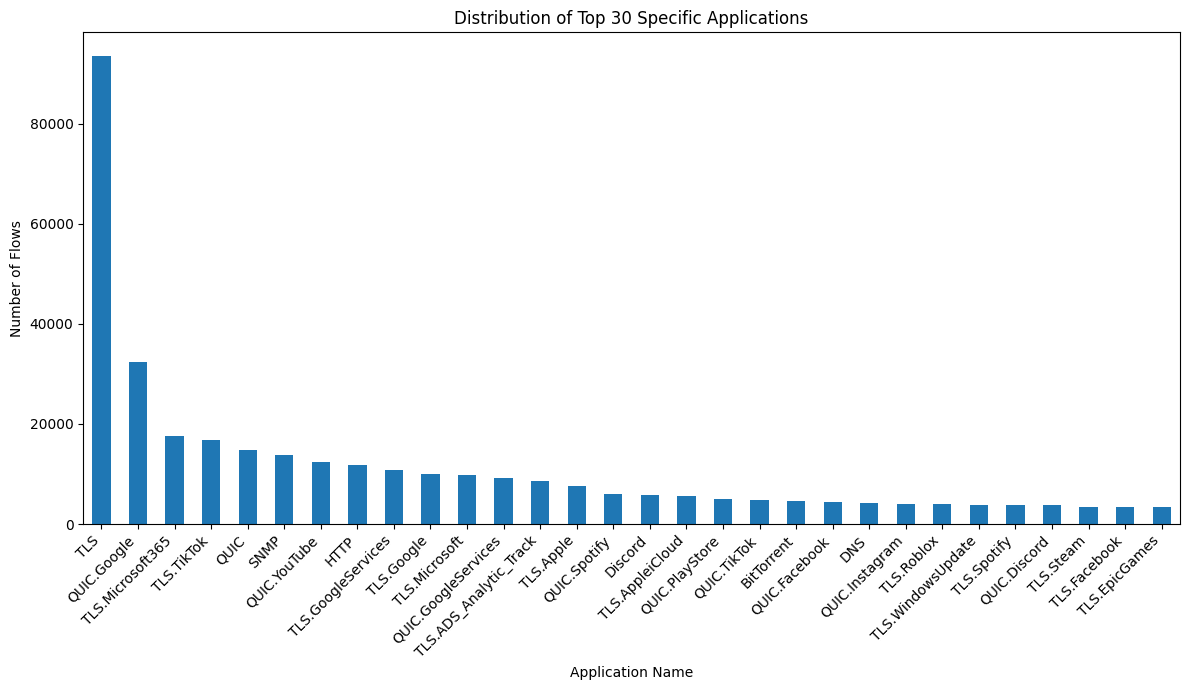

In [23]:
# Analyze the fine-grained target: application names
print("\nIndividual Application Distribution:")
print("=" * 50)
app_counts = y_fine.value_counts()
# Note: We are calculating percentage against the *cleaned* dataset size (len(y_fine))
app_percentages = (app_counts / len(y_fine)) * 100

# Create a DataFrame for nice printing, showing the Top 10 and Bottom 10
app_dist_df = pd.DataFrame({
    'Flows': app_counts,
    'Percentage': app_percentages
})
print("--- Top 10 Most Frequent Applications ---")
print(app_dist_df.head(10).to_string(formatters={'Flows': '{:,}'.format, 'Percentage': '{:.2f}%'.format}))
print("\n--- Bottom 10 Least Frequent Applications ---")
print(app_dist_df.tail(10).to_string(formatters={'Flows': '{:,}'.format, 'Percentage': '{:.2f}%'.format}))


# Visualize the fine-grained distribution
plt.figure(figsize=(12, 7))
# We will only plot the top 30 for readability
app_counts.head(30).plot(kind='bar')
plt.title('Distribution of Top 30 Specific Applications')
plt.xlabel('Application Name')
plt.ylabel('Number of Flows')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Analysis (Fine-grained):**
The fine-grained distribution presents a formidable modeling challenge, far exceeding the coarse-grained case.

-   **Heavy Concentration:** The top application, generic `TLS` (likely representing various services that nDPI couldn't pinpoint further), accounts for **21.8%** of the data. The top 10 applications collectively make up over 50% of all flows.
-   **An Extreme Long-Tail:** The most critical feature is the extreme long-tail. We have **337 unique applications**, but the distribution is incredibly sparse at the bottom. The least frequent applications appear only **once** in our dataset of ~430,000 flows.

<!-- **Implications for Modeling:** Training a model to distinguish between 337 classes, where many classes have only a handful of examples, is exceptionally difficult. A naive classifier guessing "TLS" would be ~22% accurate but would fail on 336 other applications.  -->
<!-- The performance on the minority classes will be the ultimate test of our model's effectiveness. -->

<!-- This analysis solidifies our strategy for the upcoming modeling sections. We must prioritize imbalance-aware evaluation metrics, and we may need to employ specialized techniques to have any hope of successfully classifying applications deep in the long tail. Furthermore, as we will explore in a dedicated section, visualizing performance across 337 classes requires more sophisticated techniques than a standard confusion matrix. -->

#### 3.5.3. Implications for Modeling: Setting a Minimum Sample Threshold

The analysis of our fine-grained target variable reveals a practical reality: while we have 337 unique application labels, many of them have an insufficient number of samples for a machine learning model to learn their patterns effectively. For example, our data shows at least 10 applications with only a single flow record. Training a classifier on a single sample is not feasible.

To create a meaningful and robust classification task, we must perform one final filtering step: **setting a minimum sample threshold**. This ensures that every class we try to predict has enough data for the model to learn from and for us to reliably evaluate.

**Threshold selection:** There is no single "correct" threshold; it is a trade-off between the number of classes and the quality of the model for each class.
-   A low threshold (e.g., 100 samples) would retain many classes but might result in poor performance for those minority classes.
-   A high threshold (e.g., 1000 samples) results in fewer classes but ensures that each class is well-represented, leading to a more reliable and interpretable model.

For the purpose of this tutorial, where the goal is to build and fairly compare robust classifiers, we will adopt a conservative threshold.

**Our Strategy:** We will filter the dataset to include **only applications with at least 1,000 samples**. This decision prioritizes model quality and evaluation reliability over the raw number of classes. This filtered dataset will be the final version used for training and testing in the next section.

Let's apply this filter and see what our final, refined classification task looks like.

In [24]:
# --- Apply the Minimum Sample Threshold ---
MIN_SAMPLES = 1000

# Calculate application frequencies from our fine-grained target variable
app_counts = y_fine.value_counts()
cat_counts = y_coarse.value_counts()

# Identify which applications meet the threshold
apps_to_keep = app_counts[app_counts >= MIN_SAMPLES].index

# Filter the original statistical DataFrame to keep only these applications
df_final_model_data = df_clean[df_clean['application_name'].isin(apps_to_keep)].copy()

print(f"--- Refining the Dataset with a Minimum Sample Threshold ---")
print(f"Original number of flows: {len(df_clean):,}")
print(f"Final number of flows for modeling: {len(df_final_model_data):,}")

print(f"Original number of classes: {y_fine.nunique()}")
print(f"Number of classes with >= {MIN_SAMPLES} samples: {len(apps_to_keep)}")

final_coarse_counts = df_final_model_data['application_category_name'].value_counts()
print(f"Original number of classes: {cat_counts.nunique()}")
print(f"Number of categories with >= {MIN_SAMPLES} samples: {final_coarse_counts.nunique()}")

# # --- Re-analyze the coarse-grained distribution with the final data ---
# print("\n--- Final Coarse-Grained Category Distribution ---")
# final_coarse_counts = df_final_model_data['application_category_name'].value_counts()
# print(final_coarse_counts)

--- Refining the Dataset with a Minimum Sample Threshold ---
Original number of flows: 429,597
Final number of flows for modeling: 395,051
Original number of classes: 337
Number of classes with >= 1000 samples: 63
Original number of classes: 28
Number of categories with >= 1000 samples: 19


**Analysis of Final Dataset:**
Our final filtering step has refined the problem into a well-defined and tractable, yet still challenging, classification task.

-   **Final Sample Space:** We have removed the "long-tail" classes, resulting in a final dataset of **395,051 flows**. This is still a very substantial dataset for training robust models.
-   **Fine-Grained Task:** Our fine-grained classification task is now to distinguish between **63 unique applications**, each of which is guaranteed to have at least 1,000 samples.
-   **Coarse-Grained Task:** The filtering has also consolidated our coarse-grained task. The number of application categories with at least one representative application has been reduced from 28 to a more focused **19 categories**.

This final, filtered dataset (`df_final_model_data`) is the asset we will carry forward into the next section. It is clean, reliable, and represents a classification problem that is both realistic and well-posed for a rigorous comparative analysis of machine learning models.

----

### 3.6. Creating and Saving the Final Modeling Datasets

Our data preparation journey is now complete. We have transformed the raw dataset into a high-quality, filtered collection of **395,051 flows** across **63 reliable classes**, which we have named `df_final_model_data`.

The final step is to save this data in a way that best serves the upcoming modeling sections. For this, we will make one last strategic decision.

#### 3.6.1. The "Three-Act" Modeling Strategy

While classifying 63 classes is our ultimate goal, it represents a significant challenge in both model training and, crucially, in evaluation and visualization. A 63x63 confusion matrix, for example, is unreadable and offers little insight.
To create a clear and effective learning progression, we will structure our modeling work in three distinct "acts," each with its own purpose-built dataset and learning objectives:

1.  **Act 1: The Foundational Bake-Off.** We will first tackle a smaller, curated **10-class problem** using only **statistical features**. This controlled environment is perfect for systematically comparing different ML algorithms, visually interpreting their performance using tools like confusion matrices, and exploring techniques to mitigate class imbalance problems.
2.  **Act 2: The Advanced SPLT Experiment.** We will use the **same 10-class subset** but train a model using **only the raw SPLT sequence features**. This will allow for a direct comparison of the predictive power of statistical summaries versus raw packet sequences.
3.  **Act 3: The Real-World Challenge.** Finally, we will use the full **63-class dataset** with our best model and feature set. The focus will shift to the specific challenges of "many-class" classification, including how to evaluate a model when standard visualizations fail.

**Selecting the 10 Classes:**
Our selection is not random. We have curated a list that creates a well-rounded and interesting "textbook" problem, specifically choosing popular, modern applications. The list provides:

-   **`QUIC.Google`:** High sample count, Web services (UDP/QUIC).
-   **`TLS.Microsoft365`:** High sample count, Collaborative services (TCP/TLS).
-   **`TLS.TikTok`:** High sample count, Social Media (TCP/TLS).
-   **`QUIC.YouTube`:** High sample count, Media streaming (UDP/QUIC).
-   **`QUIC.Spotify`:** Medium sample count, Music streaming (UDP/QUIC).
-   **`Discord`:** Medium sample count, Collaborative services (primarily UDP).
-   **`BitTorrent`:** Medium sample count, P2P/Download (UDP/TCP).
-   **`QUIC.Facebook`:** Medium sample count, Social Media (UDP/QUIC).
-   **`TLS.Steam`:** Lower sample count, Gaming (TCP/TLS).
-   **`TLS.EpicGames`:** Lower sample count, Gaming (TCP/TLS).

This selection ensures our 10-class dataset provides:
-   **Protocol Diversity:** A mix of TCP-based (`TLS.*`), QUIC-based (`QUIC.*`), and applications with significant UDP components (`Discord`, `BitTorrent`).
-   **Category Diversity:** A range of use cases, including Social Media (`TLS.TikTok`), Cloud/Web Services (`TLS.Microsoft365`, `QUIC.Google`), Media (`QUIC.YouTube`), Gaming (`TLS.Steam`, `TLS.EpicGames`), and P2P (`BitTorrent`).
-   **Sample Size Variety:** A realistic mix of high-frequency and lower-frequency classes, ensuring that class imbalance remains a relevant factor.

Let's now execute this plan. We will create our 10-class DataFrame, analyze its composition, and then save all the three datasets.

In [25]:
import numpy as np
import os
import pandas as pd

# --- 1. Create the 10-class subset for Acts 1 & 2 ---
ten_class_subset = [
    'QUIC.Google', 'TLS.Microsoft365', 'TLS.TikTok', 'QUIC.YouTube', 'QUIC.Spotify',
    'Discord', 'BitTorrent', 'QUIC.Facebook', 'TLS.Steam', 'TLS.EpicGames'
]
df_10_classes = df_final_model_data[df_final_model_data['application_name'].isin(ten_class_subset)].copy()
print(f"Created 10-class subset with {len(df_10_classes):,} flows.")


# --- 2. Define the feature columns for each dataset type ---
# Statistical features are all columns EXCEPT labels and the columns we need to drop
columns_to_drop = [
    'splt_direction', 'splt_ps', 'splt_piat_ms',
    'application_name', 'application_category_name' # Drop labels to get feature list
]

# Get the list of statistical feature columns
statistical_features = df_final_model_data.drop(columns=columns_to_drop, errors='ignore').columns.tolist()

# Define the SPLT and label columns
splt_features_and_labels = ['splt_direction', 'splt_ps', 'splt_piat_ms', 'application_name', 'application_category_name']
labels_only = ['application_name', 'application_category_name']


# --- 3. Create the three final DataFrames ---
# Act 1 Dataset
df_act1 = df_10_classes[statistical_features + labels_only].copy()
# Act 2 Dataset
df_act2 = df_10_classes[splt_features_and_labels].copy()
# Act 3 Dataset
df_act3 = df_final_model_data[statistical_features + labels_only].copy()

print(f"\nAct 1 Dataset (10 classes, statistical): {df_act1.shape}")
print(f"Act 2 Dataset (10 classes, SPLT):      {df_act2.shape}")
print(f"Act 3 Dataset (63 classes, statistical): {df_act3.shape}")


# --- 4. Optimize and Save ---
DATA_DIR = 'data'
os.makedirs(DATA_DIR, exist_ok=True)
ACT1_PATH = os.path.join(DATA_DIR, 'final_dataset_10_classes_statistical.parquet')
ACT2_PATH = os.path.join(DATA_DIR, 'final_dataset_10_classes_splt.parquet')
ACT3_PATH = os.path.join(DATA_DIR, 'final_dataset_63_classes_statistical.parquet')

# Downcast for efficiency
for df_to_save in [df_act1, df_act3]:
    for col in df_to_save.select_dtypes(include=['int', 'float']).columns:
        if 'int' in str(df_to_save[col].dtype):
            df_to_save[col] = pd.to_numeric(df_to_save[col], downcast='integer')
        else:
            df_to_save[col] = pd.to_numeric(df_to_save[col], downcast='float')

df_act1.to_parquet(ACT1_PATH, index=False)
df_act2.to_parquet(ACT2_PATH, index=False)
df_act3.to_parquet(ACT3_PATH, index=False)

print("\n--- Final Datasets Saved ---")
print(f"Act 1: {ACT1_PATH} ({os.path.getsize(ACT1_PATH)/1e6:.2f} MB)")
print(f"Act 2: {ACT2_PATH} ({os.path.getsize(ACT2_PATH)/1e6:.2f} MB)")
print(f"Act 3: {ACT3_PATH} ({os.path.getsize(ACT3_PATH)/1e6:.2f} MB)")

Created 10-class subset with 106,528 flows.

Act 1 Dataset (10 classes, statistical): (106528, 57)
Act 2 Dataset (10 classes, SPLT):      (106528, 5)
Act 3 Dataset (63 classes, statistical): (395051, 57)

--- Final Datasets Saved ---
Act 1: data/final_dataset_10_classes_statistical.parquet (13.29 MB)
Act 2: data/final_dataset_10_classes_splt.parquet (10.00 MB)
Act 3: data/final_dataset_63_classes_statistical.parquet (47.64 MB)


The process is complete. We have successfully generated and saved **three distinct, purpose-built datasets**, each optimized and ready for a specific "Act" in our modeling section.
-   `final_dataset_10_classes_statistical.parquet` (13.29 MB): A lean dataset for our foundational 10-class model bake-off.
-   `final_dataset_10_classes_splt.parquet` (10.00 MB): An even leaner, specialized dataset for our sequence-based feature modeling experiment.
-   `final_dataset_63_classes_statistical.parquet` (47.64 MB): Our full, high-quality dataset for the final "real-world" many-class challenge.

#### 3.6.2. Analyzing the 10-Class Subset

Let's perform a final analysis of the 10-class dataset composition to understand the specific challenges it may present for our "Act 1" and "Act 2" modeling tasks. To visualize the relationship between the fine-grained application names and their coarser categories, we use a Sankey diagram.

In [26]:
import plotly.graph_objects as go
from plotly.offline import iplot

print("--- Curated 10-Class Subset ---")
print(f"Shape of 10-class dataset: {df_act1.shape}")
print("Class Distribution:")
print(df_act1['application_name'].value_counts())
print("\nCategory Distribution:")
print(df_act1['application_category_name'].value_counts())
print("\nProtocol Distribution:")
print(df_act1['protocol'].value_counts())

# Get the mapping data
app_to_category = df_act1.groupby(['application_name', 'application_category_name']).size().reset_index(name='flow_count')

# Get counts for apps and categories
app_counts = df_act1['application_name'].value_counts()
category_counts = df_act1['application_category_name'].value_counts()

# Create lists for Sankey
apps = df_act1['application_name'].unique().tolist()
categories = df_act1['application_category_name'].unique().tolist()

# Create labels with sample counts
app_labels_with_counts = [f"{app} ({app_counts[app]})" for app in apps]
category_labels_with_counts = [f"{cat} ({category_counts[cat]})" for cat in categories]
all_labels = app_labels_with_counts + category_labels_with_counts

# Create source, target, and value lists
source = []
target = []
values = []

for _, row in app_to_category.iterrows():
    app_idx = apps.index(row['application_name'])
    cat_idx = len(apps) + categories.index(row['application_category_name'])

    source.append(app_idx)
    target.append(cat_idx)
    values.append(row['flow_count'])

# Create Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=all_labels,
        color="lightblue"
    ),
    link=dict(
        source=source,
        target=target,
        value=values
    )
)])

fig.update_layout(
    title_text="Application to Category Mapping (Sankey Diagram)",
    font_size=12,
    width=1000,
    height=600
)

fig.show(config={'staticPlot': True})

--- Curated 10-Class Subset ---
Shape of 10-class dataset: (106528, 57)
Class Distribution:
application_name
QUIC.Google         32409
TLS.Microsoft365    17523
TLS.TikTok          16764
QUIC.YouTube        12301
QUIC.Spotify         6005
Discord              5718
BitTorrent           4622
QUIC.Facebook        4340
TLS.Steam            3458
TLS.EpicGames        3388
Name: count, dtype: int64

Category Distribution:
application_category_name
Web              25982
Collaborative    23108
SocialNetwork    21104
Media            12301
Game              6846
Advertisement     6311
Music             6005
Download          4622
Cloud              249
Name: count, dtype: int64

Protocol Distribution:
protocol
17    62541
6     43987
Name: count, dtype: int64


**Observation:**
This final analysis confirms that we have created a high-quality, challenging, and realistic "textbook" problem for our main modeling section.

1.  **Class Imbalance Persists:** While less extreme than the full 63-class problem, the imbalance is still significant. The sample count ranges from over 32,000 flows for `QUIC.Google` down to ~3,400 for `TLS.EpicGames`—a ratio of nearly 10:1. This is a meaningful challenge for any classifier.
2.  **Healthy Protocol Mix:** The subset contains a healthy mix of UDP-based (62,541 flows) and TCP-based (43,987 flows) traffic, ensuring our models must learn to handle both transport protocols.
3.  **Complex Application-to-Category Mapping:** The Sankey diagram reveals a crucial complexity. While some mappings are simple one-to-one relationships (e.g., `QUIC.YouTube` flows are always categorized as `Media`), others are more complex. For instance, `TLS.EpicGames` traffic is split between the `Game` and `Advertisement` categories. This is highly realistic, as a game client often downloads both game assets and in-game ads.
4.  **A "Long-Tail" in Miniature:** Most revealing is the `Cloud` category. It has only 249 samples, sourced from both `QUIC.Google` and `QUIC.Facebook`. This creates a perfect "miniature" version of the long-tail problem. Even in this smaller dataset, our models will be severely tested on their ability to identify this very rare but distinct category.

This analysis confirms that our 10-class subset is a well-rounded and representative problem.

----

## 3. Conclusion

This section has executed a comprehensive, end-to-end data preparation pipeline. We began with a raw, 89-feature dataset, full of potential pitfalls, and have systematically transformed it into high-quality, reliable datasets ready for machine learning.

This was not a simple, linear process, but an iterative journey of discovery and refinement. Through this, we have demonstrated several principles that are critical for any real-world network traffic analysis project:

1.  **The Primacy of Exploration:** We first built a deep understanding of the data by analyzing its fundamental characteristics, from its capture window and protocol distributions to the complex, protocol-dependent nature of its features.
2.  **The Rigor of Quality Assessment:** We systematically identified and quantified numerous data quality issues, including structurally missing values, constant features, and the large volume of unlabeled or low-confidence flows.
3.  **The Power of Iterative Cleaning:** We demonstrated that data cleaning is not a one-shot process. By re-checking data properties after our initial row filtering, we uncovered newly constant features, proving the need for an iterative approach.
4.  **The Necessity of Principled Filtering:** Based on our analysis, we executed a multi-stage filtering strategy, justifying each decision—from removing guessed labels to setting a minimum packet count—to distill our dataset down to only the most substantive flows.
5.  **The Refinement of the Task:** We analyzed our target variable and made a crucial, data-driven decision to refine our fine-grained problem from 337 to 63 classes with sufficient samples for robust modeling.
6.  **The Strategic Creation of Subsets:** Finally, we made a deliberate, pedagogical decision to create a curated **10-class subset** to facilitate a clear and interpretable comparison of models before tackling the full, complex problem.

The result of this work is a **trio of purpose-built, analysis-ready datasets**. They are the product of a transparent, justified, and rigorous preparation process.
<!-- These foundational assets are now ready to be carried forward into the next section, where we will use them to build, compare, and evaluate a suite of supervised machine learning models. -->
